# Clustering pages by text-line layout

This notebook demonstrates `archival_structures.analysis.page_layout_clustering`: clustering
whole pages by the spatial layout of their text lines (not regions -- region detection is too
crude and merges visually distinct elements). It builds on
`archival_structures.analysis.grid_analysis.GridPattern`, which grids each page by its line
geometry and computes a TF-IDF vector per page over small recurring grid patterns; this module
just clusters those vectors with HDBSCAN.

One implementation detail worth knowing if you reuse this elsewhere: TF-IDF row norms vary a
lot between pages (a page with more text has a "longer" vector even if its pattern *composition*
is identical to a shorter page), which would otherwise dominate Euclidean distance and produce
all-noise clustering. `cluster_page_layouts` L2-normalises the rows before clustering to correct
for that.

This uses `NL-HaNA_2.10.50_1`, one of the book-of-openings inventory numbers, and -- as with the
line-clustering demo -- **splits each two-page opening into single pages first** with
`archival_structures.analysis.opening_detection.split_inventory_into_pages`. A page's layout is a
property of *that page*, not of the two-page scan it happened to be photographed alongside, so
clustering should operate on pages, not opening-wide scans.

In [ ]:
from pathlib import Path

import pandas as pd
from PIL import Image, ImageDraw
import pagexml.parser as pagexml_parser

from archival_structures.analysis.opening_detection import (
    classify_inventory_structure, split_inventory_into_pages, get_opening_features,
)
from archival_structures.analysis.page_layout_clustering import cluster_page_layouts

INSTITUTE = 'NL-HaNA'
ARCHIVE = 'NL-HaNA_2.10.50'
INVENTORY_NUM = 'NL-HaNA_2.10.50_1'
PAGEXML_DIR = Path('../../data/PageXML') / INSTITUTE / ARCHIVE / INVENTORY_NUM
THUMB_DIR = Path('../../data/thumbs') / INSTITUTE / ARCHIVE / INVENTORY_NUM

assert PAGEXML_DIR.exists(), PAGEXML_DIR
assert THUMB_DIR.exists(), THUMB_DIR

## Load a sample of scans, split openings into pages, and cluster them

`GridPattern` turns out not to tolerate pages with zero lines well (an empty page's all-zero
grid pollutes the global pattern vocabulary enough that clustering degenerates to all-noise) --
filter those out, which a real "page" should rarely be anyway.

In [ ]:
xml_paths = sorted(PAGEXML_DIR.glob('*.xml'))[:60]
scans = [pagexml_parser.parse_pagexml_file(str(xml_path)) for xml_path in xml_paths]
scans_by_id = {scan.id: scan for scan in scans}
print(f"loaded {len(scans)} scans")

structure = classify_inventory_structure(scans)
print(f"inventory structure: {structure.structure_type} {structure.type_counts}")

all_pages = split_inventory_into_pages(scans, structure=structure)
pages = [page for page in all_pages if len(page.get_lines()) > 0]
page_by_id = {page.id: page for page in pages}
print(f"{len(scans)} scans -> {len(all_pages)} pages -> {len(pages)} with at least one line")

clusters, grid_pattern = cluster_page_layouts(pages, unit_size=50, pattern_size=3, min_cluster_size=4)
print("\ncluster sizes:")
print(clusters.value_counts().sort_index())

## Sanity-check the clusters against simple structural stats

These stats (region/line counts) aren't what the clustering is based on, so a clear difference
between clusters here is independent evidence that the clusters correspond to genuinely
different page structures, not an artefact of the layout features themselves.

In [ ]:
stats_rows = [{'page_id': page.id, 'n_regions': len(page.text_regions), 'n_lines': len(page.get_lines()),
              'cluster': clusters[page.id]} for page in pages]
stats_df = pd.DataFrame(stats_rows)
stats_df.groupby('cluster')[['n_regions', 'n_lines']].agg(['mean', 'std', 'count'])

## Look at example pages from each cluster

This draws each example page's line outlines on top of its actual scan thumbnail
(`data/thumbs/NL-HaNA/NL-HaNA_2.10.50/NL-HaNA_2.10.50_1`) -- a split page's thumbnail is the
relevant cropped half of its original opening's thumbnail, the same approach used in the
line-clustering notebook's visualisation. Pick a couple of representative pages per cluster and
display them side by side with the structural stats above.

In [ ]:
def original_scan_id(page_id: str) -> str:
    for suffix in ('-verso', '-recto'):
        if page_id.endswith(suffix):
            return page_id[:-len(suffix)]
    return page_id


def page_thumbnail(page) -> Image.Image:
    """Load `page`'s thumbnail. For a split verso/recto page this is the corresponding half of
    its original opening's thumbnail, cropped at the same separation point used to split the
    PageXML (recomputed here since `split_inventory_into_pages` doesn't keep it around)."""
    scan_id = original_scan_id(page.id)
    image = Image.open(THUMB_DIR / scan_id).convert('RGB')
    if page.id == scan_id:
        return image
    scan = scans_by_id[scan_id]
    scale = image.width / scan.coords.width
    sep_x = round(get_opening_features(scan).separation_point.x * scale)
    return image.crop((0, 0, sep_x, image.height)) if page.id.endswith('-verso') \
        else image.crop((sep_x, 0, image.width, image.height))


def draw_page_outline(page) -> Image.Image:
    """Draw `page`'s line outlines on top of its thumbnail."""
    image = page_thumbnail(page).copy()
    scale = image.width / page.coords.width
    draw = ImageDraw.Draw(image)
    for line in page.get_lines():
        x, y = line.coords.left * scale, line.coords.top * scale
        w, h = line.coords.width * scale, line.coords.height * scale
        draw.rectangle([x, y, x + w, y + h], outline='red', width=1)
    return image


def show_cluster_examples(cluster_id, n=2):
    page_ids = clusters[clusters == cluster_id].index[:n]
    label = 'noise' if cluster_id == -1 else f'cluster {cluster_id}'
    print(f"{label}: {list(page_ids)}")
    images = [draw_page_outline(page_by_id[page_id]) for page_id in page_ids]
    if not images:
        return None
    width = sum(im.width for im in images)
    height = max(im.height for im in images)
    combined = Image.new('RGB', (width, height), 'white')
    x = 0
    for im in images:
        combined.paste(im, (x, 0))
        x += im.width
    return combined


show_cluster_examples(0)

cluster 1: ['NL-AsnDA_0114.11_1_0009.jpg', 'NL-AsnDA_0114.11_1_0010.jpg']


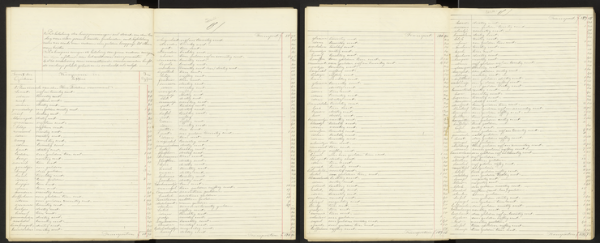

In [5]:
show_cluster_examples(1)

## Visualise with UMAP

Project the (L2-normalised) TF-IDF vectors to 2D with `colour_clustering.project_umap` -- reusing
the same UMAP helper already used for colour clustering -- purely for visual inspection of how
well-separated the clusters are.

/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


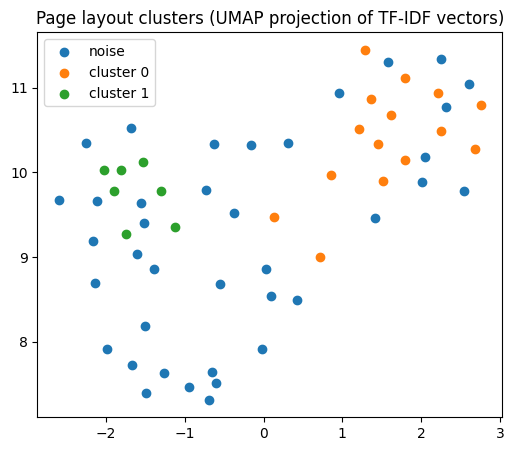

In [6]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize

from archival_structures.clustering.colour_clustering import project_umap

umap_coords = project_umap(normalize(grid_pattern.tfidf), n_neighbors=10)

fig, ax = plt.subplots(figsize=(6, 5))
for cluster_id in sorted(clusters.unique()):
    mask = (clusters.values == cluster_id)
    label = 'noise' if cluster_id == -1 else f'cluster {cluster_id}'
    ax.scatter(umap_coords[mask, 0], umap_coords[mask, 1], label=label)
ax.legend()
ax.set_title('Page layout clusters (UMAP projection of TF-IDF vectors)')
plt.show()